# Tutorial 6: Stellar populations

Everything a semi-analytic model knows about stars enters through a small
set of `functionClass` families: the initial mass function (IMF), stellar
astrophysics (lifetimes, remnant and ejected masses, yields), and the
supernova rates built on top of them. All are driven directly from Python
here.

This tutorial needs the Galacticus *datasets* (the stellar-properties
compilation) — see the setup cell.

In [1]:
import os, sys

# Locate the Galacticus library interface (see Tutorial 1 for details).
root = os.environ.get('GALACTICUS_LIBRARY_PATH',
                      os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
os.chdir(root)   # galacticus.py loads galacticus/lib/libgalacticus.so relative to here
for candidate in (root, os.path.join(root, 'galacticus', 'python')):
    if os.path.exists(os.path.join(candidate, 'galacticus.py')):
        sys.path.insert(0, candidate)
        break
else:
    raise RuntimeError(f"galacticus.py not found under {root} - build the library "
                       "(make GALACTICUS_BUILD_OPTION=lib libgalacticus.so) or set "
                       "GALACTICUS_LIBRARY_PATH")

# This tutorial also reads Galacticus's static datasets (the stellar
# properties compilation): clone https://github.com/galacticusorg/datasets
# and point GALACTICUS_DATA_PATH at it.
if 'GALACTICUS_DATA_PATH' not in os.environ:
    raise RuntimeError("set GALACTICUS_DATA_PATH to a clone of "
                       "https://github.com/galacticusorg/datasets")

import numpy as np
if not hasattr(np, 'trapezoid'):        # np.trapezoid is NumPy >= 2.0;
    np.trapezoid = np.trapz             # fall back to the pre-2.0 name.
import matplotlib.pyplot as plt
import galacticus
print("Galacticus library interface loaded.")

Galacticus library interface loaded.


In [2]:
plt.rcParams.update({'figure.figsize': (7.0, 4.5), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})

## Initial mass functions

`phi(m)` returns $\phi(m) = \mathrm{d}N/\mathrm{d}m$ per unit stellar
mass formed — each IMF is normalized so $\int m\,\phi(m)\,\mathrm{d}m
= 1$. We compare the three classics; the Chabrier (2001) parameters shown
are Galacticus's defaults (lognormal below $1\,M_\odot$, power law
above).

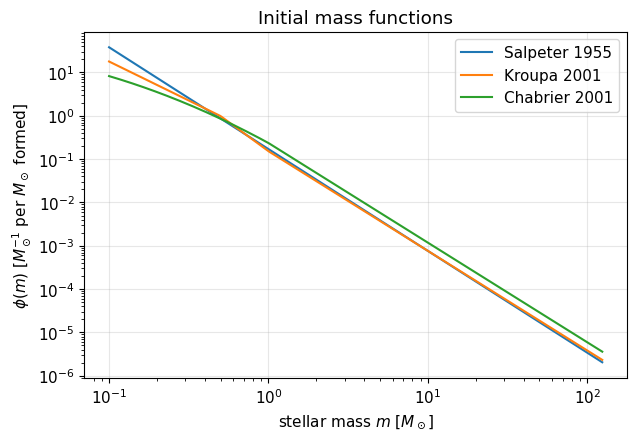

Salpeter 1955 : integral of m*phi(m) dm = 1.0000
Kroupa 2001   : integral of m*phi(m) dm = 1.0000
Chabrier 2001 : integral of m*phi(m) dm = 1.0000


In [3]:
imfSalpeter = galacticus.initialMassFunctionSalpeter1955()
imfKroupa   = galacticus.initialMassFunctionKroupa2001()
imfChabrier = galacticus.initialMassFunctionChabrier2001(
    massLower=0.1, massTransition=1.0, massUpper=125.0,
    exponent=-2.3, massCharacteristic=0.08, sigma=0.69)
imfs = (('Salpeter 1955', imfSalpeter), ('Kroupa 2001', imfKroupa),
        ('Chabrier 2001', imfChabrier))

masses = np.logspace(-1, np.log10(124.0), 300)
for label, imf in imfs:
    plt.loglog(masses, [imf.phi(m) for m in masses], label=label)
plt.xlabel('stellar mass $m$ [$M_\\odot$]')
plt.ylabel('$\\phi(m)$ [$M_\\odot^{-1}$ per $M_\\odot$ formed]')
plt.legend(); plt.title('Initial mass functions')
plt.show()

# Verify the unit mass normalization by direct integration of phi.
for label, imf in imfs:
    grid = np.logspace(np.log10(imf.massMinimum()), np.log10(imf.massMaximum()), 8001)
    norm = np.trapezoid([m*imf.phi(m) for m in grid], grid)
    print(f"{label:14s}: integral of m*phi(m) dm = {norm:.4f}")

Astrophysically the differences live at the extremes: Salpeter's unbroken
power law puts far more mass into (invisible, long-lived) low-mass stars,
while the turned-over IMFs put relatively more into the massive stars
that drive supernova feedback. `numberCumulative` integrates the count —
here, core-collapse supernova progenitors ($8$–$125\,M_\odot$) per solar
mass of stars formed:

In [4]:
for label, imf in imfs:
    print(f"{label:14s}: {imf.numberCumulative(8.0, 125.0):.5f} SN II progenitors per Msun formed")

Salpeter 1955 : 0.00743 SN II progenitors per Msun formed
Kroupa 2001   : 0.00761 SN II progenitors per Msun formed
Chabrier 2001 : 0.01179 SN II progenitors per Msun formed


## Stellar astrophysics: lifetimes, remnants and yields

`stellarAstrophysicsFile` interpolates the standard compilation of
stellar-evolution models shipped with Galacticus (the
`%DATASTATICPATH%` token expands to the static datasets path). Three
textbook results in three plots: the steep lifetime-mass relation and its
weak metallicity dependence, the main-sequence turnoff mass as a clock,
and how much of a star's mass is returned to the interstellar medium.

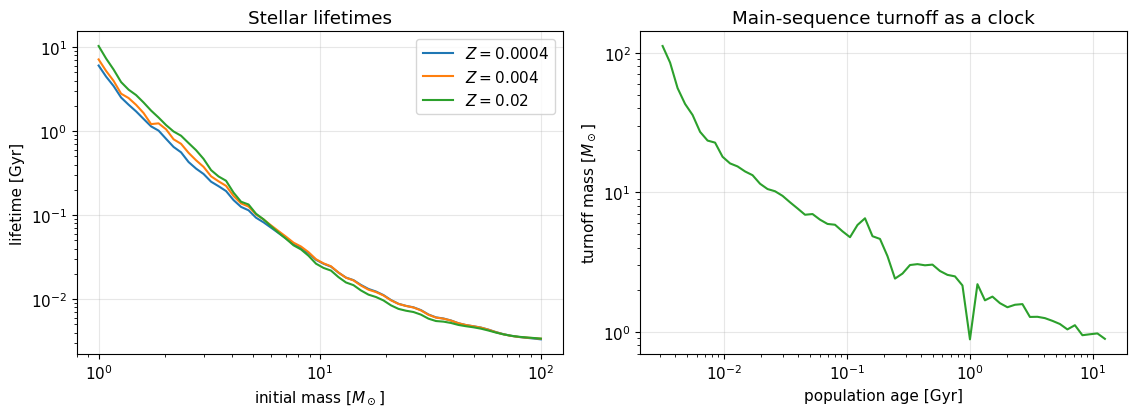

Solar-mass, solar-metallicity lifetime: 10.3 Gyr


In [5]:
stellarAstrophysics = galacticus.stellarAstrophysicsFile(
    "%DATASTATICPATH%/stellarAstrophysics/stellarPropertiesCompilationStandard.xml")

massGrid = np.logspace(0.0, 2.0, 60)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
for Z, color in ((0.0004, 'C0'), (0.004, 'C1'), (0.02, 'C2')):
    axes[0].loglog(massGrid, [stellarAstrophysics.lifetime(m, Z) for m in massGrid],
                   color=color, label=f'$Z={Z}$')
axes[0].set_xlabel('initial mass [$M_\\odot$]'); axes[0].set_ylabel('lifetime [Gyr]')
axes[0].legend(); axes[0].set_title('Stellar lifetimes')

ages = np.logspace(-2.5, 1.1, 60)
axes[1].loglog(ages, [stellarAstrophysics.massInitial(age, 0.02) for age in ages], color='C2')
axes[1].set_xlabel('population age [Gyr]'); axes[1].set_ylabel('turnoff mass [$M_\\odot$]')
axes[1].set_title('Main-sequence turnoff as a clock')
fig.tight_layout(); plt.show()

print(f"Solar-mass, solar-metallicity lifetime: "
      f"{stellarAstrophysics.lifetime(1.0, 0.02):.1f} Gyr")

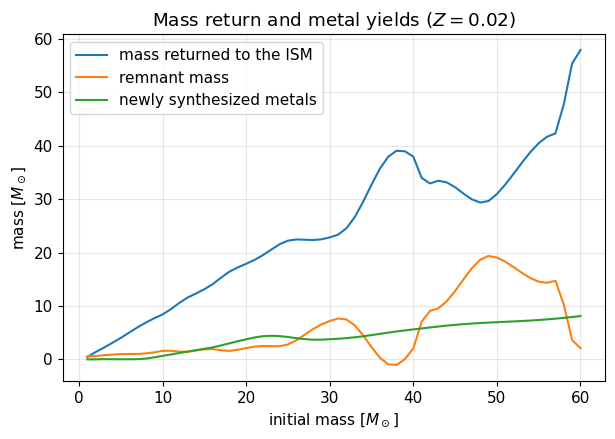

In [6]:
massGrid = np.linspace(1.0, 60.0, 60)
ejected  = np.array([stellarAstrophysics.massEjected(m, 0.02) for m in massGrid])
yieldMetals = np.array([stellarAstrophysics.massYield(m, 0.02) for m in massGrid])
plt.plot(massGrid, ejected          , label='mass returned to the ISM')
plt.plot(massGrid, massGrid-ejected , label='remnant mass')
plt.plot(massGrid, yieldMetals      , label='newly synthesized metals')
plt.xlabel('initial mass [$M_\\odot$]'); plt.ylabel('mass [$M_\\odot$]')
plt.legend(); plt.title('Mass return and metal yields ($Z=0.02$)')
plt.show()

## Type Ia supernova delay-time distribution

Type Ia supernovae trace *old* populations: after a minimum delay for the
first white dwarfs to form, the rate falls off roughly as $t^{-1}$.
`supernovaeTypeIaPowerLawDTDDifferential.number` gives the cumulative
number of SNe Ia per solar mass formed by a given population age (the
$2\times10^{-3}\,M_\odot^{-1}$ normalization and $t^{-1}$ slope follow
Maoz et al. 2012).

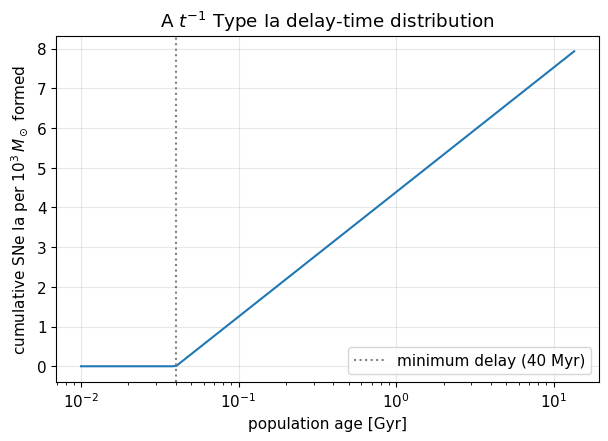

SNe Ia per Msun formed within 10 Gyr: 7.522e-03


In [7]:
snIa = galacticus.supernovaeTypeIaPowerLawDTDDifferential(
    timeMinimum=0.04, exponent=-1.0, normalization=2.0e-3)
ages = np.logspace(-2, 1.13, 120)
number = np.array([snIa.number(imfChabrier, 1.0, age, 0.02) for age in ages])
plt.semilogx(ages, 1.0e3*number)
plt.axvline(0.04, color='gray', ls=':', label='minimum delay (40 Myr)')
plt.xlabel('population age [Gyr]')
plt.ylabel('cumulative SNe Ia per $10^3\\,M_\\odot$ formed')
plt.legend(); plt.title('A $t^{-1}$ Type Ia delay-time distribution')
plt.show()
print(f"SNe Ia per Msun formed within 10 Gyr: {snIa.number(imfChabrier, 1.0, 10.0, 0.02):.3e}")

## What about full spectra?

Simple-stellar-population *spectra* (`stellarPopulationSpectraFSPS`) are
exposed through the same interface, but constructing that class triggers,
on first use, a download-compile-run of the
[FSPS](https://github.com/cconroy20/fsps) package to tabulate the spectra
— too heavy for a tutorial that executes in CI. If you have a Galacticus
installation that has already built its FSPS tables, the class works from
Python like any other; spectral evaluation per-wavelength additionally
requires an `abundances` object, which the library interface does not yet
construct from Python.

## Where next

These classes are the atoms from which Galacticus builds its chemical
evolution and feedback: `stellarPopulationProperties` integrates them over
star-formation histories, and `stellarFeedback` turns them into energy
injection. Combined with Tutorials 3 and 5, you now have the full chain
from the power spectrum to the stars.